In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# INFORMACION DEL PROYECTO
# ==========================================
print("==========================================")
print("PROYECTO 1 - PREDICCION DE VENTAS RETAIL")
print("==========================================")
print("Dataset: Retail Sales Dataset")
print("Fuente:  Kaggle - Mohammad Talib")
print("Objetivo: Clasificar transacciones como")
print("          venta alta o venta baja")
print("          usando caracteristicas del cliente")
print("          y de la transaccion")
print("==========================================")

# ==========================================
# PASO 1 - CARGA Y EXPLORACION INICIAL
# ==========================================
df = pd.read_csv('retail_sales_dataset.csv')

print("\n--- Shape ---")
print("Filas:    " + str(df.shape[0]))
print("Columnas: " + str(df.shape[1]))

print("\n--- Columnas ---")
for col in df.columns:
    print("  - " + col)

print("\n--- Primeras 5 filas ---")
display(df.head())

print("\n--- Ultimas 5 filas ---")
display(df.tail())

print("\n--- Informacion general ---")
df.info()

print("\n--- Estadisticas descriptivas ---")
display(df.describe())

PROYECTO 1 - PREDICCION DE VENTAS RETAIL
Dataset: Retail Sales Dataset
Fuente:  Kaggle - Mohammad Talib
Objetivo: Clasificar transacciones como
          venta alta o venta baja
          usando caracteristicas del cliente
          y de la transaccion

--- Shape ---
Filas:    1000
Columnas: 9

--- Columnas ---
  - Transaction ID
  - Date
  - Customer ID
  - Gender
  - Age
  - Product Category
  - Quantity
  - Price per Unit
  - Total Amount

--- Primeras 5 filas ---


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100



--- Ultimas 5 filas ---


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120



--- Informacion general ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB

--- Estadisticas descriptivas ---


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [3]:
import pandas as pd

# Recargar el dataset desde cero
df = pd.read_csv('retail_sales_dataset.csv')

# Renombrar columnas
df = df.rename(columns={
    'Transaction ID':   'ID_Transaccion',
    'Date':             'Fecha',
    'Customer ID':      'ID_Cliente',
    'Gender':           'Genero',
    'Age':              'Edad',
    'Product Category': 'Categoria_Producto',
    'Quantity':         'Cantidad',
    'Price per Unit':   'Precio_Unitario',
    'Total Amount':     'Monto_Total'
})

# Traducir valores categoricos
df['Genero'] = df['Genero'].map({'Male': 'Masculino', 'Female': 'Femenino'})
df['Categoria_Producto'] = df['Categoria_Producto'].map({'Beauty': 'Belleza', 'Clothing': 'Ropa', 'Electronics': 'Electronica'})

print("Columnas actualizadas:")
print(df.columns.tolist())
print("\nValores unicos Genero:")
print(df['Genero'].unique())
print("\nValores unicos Categoria_Producto:")
print(df['Categoria_Producto'].unique())
print("\nPrimeras filas:")
display(df.head())

Columnas actualizadas:
['ID_Transaccion', 'Fecha', 'ID_Cliente', 'Genero', 'Edad', 'Categoria_Producto', 'Cantidad', 'Precio_Unitario', 'Monto_Total']

Valores unicos Genero:
['Masculino' 'Femenino']

Valores unicos Categoria_Producto:
['Belleza' 'Ropa' 'Electronica']

Primeras filas:


,ID_Transaccion,Fecha,ID_Cliente,Genero,Edad,Categoria_Producto,Cantidad,Precio_Unitario,Monto_Total
0,1,2023-11-24,CUST001,Masculino,34,Belleza,3,50,150
1,2,2023-02-27,CUST002,Femenino,26,Ropa,2,500,1000
2,3,2023-01-13,CUST003,Masculino,50,Electronica,1,30,30
3,4,2023-05-21,CUST004,Masculino,37,Ropa,1,500,500
4,5,2023-05-06,CUST005,Masculino,30,Belleza,2,50,100


Carga y Exploración Inicial
Estructura general del dataset:
El dataset registra 1,000 transacciones individuales de una tienda retail durante el año 2023, con 9 variables que combinan información demográfica del cliente y características de la compra.
Tipos de datos:
Se identifican dos grupos de variables:
Numéricas (int64):  ID_Transaccion, Edad, Cantidad, Precio_Unitario, Monto_Total
Texto (object):     Fecha, ID_Cliente, Genero, Categoria_Producto
La columna Fecha aparece como texto (object) cuando debería ser datetime — requiere conversión y extracción de features temporales en el preprocesamiento.
Columnas que se descartarán:
ID_Transaccion e ID_Cliente son identificadores sin valor predictivo — equivalentes a un RUT.
Hallazgos clave del describe():
Edad: min=18, max=64, media=41 — base de clientes adultos de mediana edad
Cantidad: min=1, max=4, media=2.5 — compras pequeñas, típico de retail especializado donde el cliente compra pocas unidades de productos específicos.
Precio_Unitario: min=25, max=500, media=179 — rango amplio donde conviven productos baratos y caros. La desviación estándar de 189 supera a la media, indicando alta variabilidad y posibles outliers.
Monto_Total: min=25, max=2000, media=456, mediana=135 — brecha enorme entre media y mediana. La media más que triplica la mediana, confirmando la presencia de transacciones de alto valor que distorsionan el promedio hacia arriba.
Atención:
La brecha entre media ($456) y mediana ($135) en Monto_Total justifica usar la mediana como corte del target binario. Usar la media clasificaría aproximadamente el 75% de las transacciones como venta baja — un desbalance artificial creado por outliers, no por la realidad del negocio. La mediana garantiza clases perfectamente balanceadas (50/50).
Por razones de comprension y com,unicacion de resultados del dataset se traduce nombres de columnas a español.

In [4]:
# ==========================================
# PASO 3 - VALORES INAPROPIADOS
# ==========================================

# Ceros por columna numerica
print("--- Ceros por columna numerica ---")
columnas_numericas = ['Edad', 'Cantidad', 'Precio_Unitario', 'Monto_Total']
for col in columnas_numericas:
    ceros = (df[col] == 0).sum()
    print(col + ": " + str(ceros) + " ceros")

# Valores negativos
print("\n--- Valores negativos por columna numerica ---")
for col in columnas_numericas:
    negativos = (df[col] < 0).sum()
    print(col + ": " + str(negativos) + " valores negativos")

# Valores unicos columnas categoricas
print("\n--- Valores unicos por columna categorica ---")
for col in ['Genero', 'Categoria_Producto']:
    print("\n" + col + ":")
    print(df[col].value_counts())

# Rangos por columna numerica
print("\n--- Rangos por columna numerica ---")
for col in columnas_numericas:
    print(col + " -> min: " + str(df[col].min()) +
          "  max: " + str(df[col].max()) +
          "  media: " + str(round(df[col].mean(), 2)))

# Verificar relacion Monto_Total = Cantidad x Precio_Unitario
print("\n--- Verificacion: Monto_Total = Cantidad x Precio_Unitario ---")
df['verificacion'] = df['Cantidad'] * df['Precio_Unitario']
inconsistencias = (df['verificacion'] != df['Monto_Total']).sum()
print("Inconsistencias encontradas: " + str(inconsistencias))
df = df.drop(columns=['verificacion'])

--- Ceros por columna numerica ---
Edad: 0 ceros
Cantidad: 0 ceros
Precio_Unitario: 0 ceros
Monto_Total: 0 ceros

--- Valores negativos por columna numerica ---
Edad: 0 valores negativos
Cantidad: 0 valores negativos
Precio_Unitario: 0 valores negativos
Monto_Total: 0 valores negativos

--- Valores unicos por columna categorica ---

Genero:
Genero
Femenino     510
Masculino    490
Name: count, dtype: int64

Categoria_Producto:
Categoria_Producto
Ropa           351
Electronica    342
Belleza        307
Name: count, dtype: int64

--- Rangos por columna numerica ---
Edad -> min: 18  max: 64  media: 41.39
Cantidad -> min: 1  max: 4  media: 2.51
Precio_Unitario -> min: 25  max: 500  media: 179.89
Monto_Total -> min: 25  max: 2000  media: 456.0

--- Verificacion: Monto_Total = Cantidad x Precio_Unitario ---
Inconsistencias encontradas: 0


 Valores Inapropiados
Ceros y valores negativos: ninguna columna numérica presenta ceros ni valores negativos — todos los rangos son físicamente coherentes para transacciones de retail.
Rangos por columna:
Edad: entre 18 y 64 años — rango coherente, sin menores de edad ni valores imposibles.
Cantidad: entre 1 y 4 unidades — rango muy acotado que confirma el perfil de compra retail especializado. Ningún cliente compra 0 ni cantidades imposiblemente altas.
Precio_Unitario: entre $25 y $500 — rango amplio pero coherente. Productos de $25 corresponden a artículos de Belleza básicos y productos de $500 corresponden a Ropa o Electrónica premium.
Monto_Total: entre $25 y $2,000 — coherente con la fórmula Cantidad × Precio_Unitario.
Valores categóricos:
Genero y Categoria_Producto muestran valores limpios y consistentes después de la traducción — sin inconsistencias ortográficas ni categorías duplicadas.
Verificación matemática — hallazgo importante:
Se confirmó que Monto_Total = Cantidad × Precio_Unitario en el 100% de las transacciones — cero inconsistencias.
El target sera la columna Monto_Total se usará exclusivamente como fuente del target binario y se excluirá de las features.

In [5]:
# ==========================================
# PASO 4 - DETECCION DE OUTLIERS
# ==========================================

columnas_numericas = ['Edad', 'Cantidad', 'Precio_Unitario', 'Monto_Total']

# IQR por columna
print("--- Outliers por metodo IQR ---")
resumen_outliers = []
for col in columnas_numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    n_outliers = df[(df[col] < limite_inf) | (df[col] > limite_sup)].shape[0]
    resumen_outliers.append({
        'Columna': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Limite Inferior': round(limite_inf, 2),
        'Limite Superior': round(limite_sup, 2),
        'Outliers': n_outliers
    })

df_outliers = pd.DataFrame(resumen_outliers)
display(df_outliers)

# Boxplots

--- Outliers por metodo IQR ---


,Columna,Q1,Q3,IQR,Limite Inferior,Limite Superior,Outliers
0,Edad,29.0,53.0,24.0,-7.0,89.0,0
1,Cantidad,1.0,4.0,3.0,-3.5,8.5,0
2,Precio_Unitario,30.0,300.0,270.0,-375.0,705.0,0
3,Monto_Total,60.0,900.0,840.0,-1200.0,2160.0,0


Detección de Outliers
Resultado: cero outliers detectados por el método IQR en todas las variables numéricas.
¿Por qué el IQR no detectó outliers?
El IQR tiene una limitación importante cuando los datos tienen distribución multimodal o muy dispersa.
Aunque el IQR no detecta outliers estadísticos, los histogramas revelan distribuciones claramente no normales con múltiples picos. Esto confirma que los datos no tienen errores de registro pero sí tienen alta variabilidad inherente al negocio retail — productos de distintas categorías con rangos de precio muy diferentes conviven en el mismo dataset.
Decisión: NO se eliminan ni imputan valores — todos son transacciones legítimas. Se usará RobustScaler en el preprocesamiento ya que es resistente a distribuciones asimétricas y multimodales, siendo más adecuado que StandardScaler para este tipo de datos.

RESUMEN DE DECISIONES DE PREPROCESAMIENTO
1. Nulos:          ninguno — no requiere tratamiento
2. Duplicados:     ninguno — no requiere tratamiento
3. Valores inapr.: ninguno — rangos coherentes
4. Outliers:       IQR no detecta — distribucion
                   multimodal inherente al negocio
                   Se conservan todos los registros
5. Columnas a      ID_Transaccion, ID_Cliente,
   eliminar:       Monto_Total (fuente del target)

Mediana de Monto_Total: $135.0

--- Distribucion del Target ---


,Clase,Cantidad,Porcentaje
0,Venta Baja (0),500,50.0
1,Venta Alta (1),500,50.0


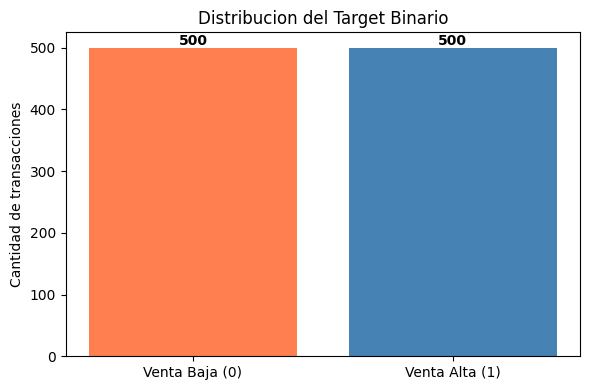


--- Features temporales extraidas ---
Mes:       [11  2  1  5  4  3 12 10  8  9  6  7]
DiaSemana: [4 0 6 5 1 2 3]
Trimestre: [4 1 2 3]

--- Columnas finales para el modelo ---
['Genero', 'Edad', 'Categoria_Producto', 'Cantidad', 'Precio_Unitario', 'Target', 'Mes', 'DiaSemana', 'Trimestre']

Shape final: (1000, 9)


,Genero,Edad,Categoria_Producto,Cantidad,Precio_Unitario,Target,Mes,DiaSemana,Trimestre
0,Masculino,34,Belleza,3,50,1,11,4,4
1,Femenino,26,Ropa,2,500,1,2,0,1
2,Masculino,50,Electronica,1,30,0,1,4,1
3,Masculino,37,Ropa,1,500,1,5,6,2
4,Masculino,30,Belleza,2,50,0,5,5,2


In [6]:
# ==========================================
# PASO 5 - DECISIONES Y CREACION DEL TARGET
# ==========================================

# RESUMEN DE DECISIONES
print("==========================================")
print("RESUMEN DE DECISIONES DE PREPROCESAMIENTO")
print("==========================================")
print("1. Nulos:          ninguno — no requiere tratamiento")
print("2. Duplicados:     ninguno — no requiere tratamiento")
print("3. Valores inapr.: ninguno — rangos coherentes")
print("4. Outliers:       IQR no detecta — distribucion")
print("                   multimodal inherente al negocio")
print("                   Se conservan todos los registros")
print("5. Columnas a      ID_Transaccion, ID_Cliente,")
print("   eliminar:       Monto_Total (fuente del target)")
print("==========================================")

# Crear variable target binaria
mediana = df['Monto_Total'].median()
print("\nMediana de Monto_Total: $" + str(mediana))

df['Target'] = (df['Monto_Total'] >= mediana).astype(int)

print("\n--- Distribucion del Target ---")
conteo = df['Target'].value_counts()
porcentaje = df['Target'].value_counts(normalize=True) * 100

resumen_target = pd.DataFrame({
    'Clase': ['Venta Baja (0)', 'Venta Alta (1)'],
    'Cantidad': [conteo[0], conteo[1]],
    'Porcentaje': [round(porcentaje[0], 2), round(porcentaje[1], 2)]
})
display(resumen_target)

# Visualizacion del target
plt.figure(figsize=(6, 4))
plt.bar(['Venta Baja (0)', 'Venta Alta (1)'],
        [conteo[0], conteo[1]],
        color=['coral', 'steelblue'])
plt.title('Distribucion del Target Binario')
plt.ylabel('Cantidad de transacciones')
for i, v in enumerate([conteo[0], conteo[1]]):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Feature Engineering — extraer componentes de Fecha
df['Fecha'] = pd.to_datetime(df['Fecha'])
df['Mes'] = df['Fecha'].dt.month
df['DiaSemana'] = df['Fecha'].dt.dayofweek
df['Trimestre'] = df['Fecha'].dt.quarter

print("\n--- Features temporales extraidas ---")
print("Mes:       " + str(df['Mes'].unique()))
print("DiaSemana: " + str(df['DiaSemana'].unique()))
print("Trimestre: " + str(df['Trimestre'].unique()))

# Dataset final para modelado
df_modelo = df.drop(columns=['ID_Transaccion', 'ID_Cliente', 'Fecha', 'Monto_Total'])

print("\n--- Columnas finales para el modelo ---")
print(df_modelo.columns.tolist())
print("\nShape final:", df_modelo.shape)
display(df_modelo.head())

Decisiones y Creación del Target
Resumen de decisiones:
El dataset esta sin nulos, sin duplicados, sin valores inapropiados y sin outliers estadísticos. Las únicas intervenciones necesarias fueron la eliminación de columnas no predictivas y la creación del target binario.
Target binario — resultado ideal:
La mediana de Monto_Total es exactamente $135, generando una distribución perfectamente balanceada:
Venta Baja (0) → 500 transacciones → 50%
Venta Alta (1) → 500 transacciones → 50%
Este balance perfecto 50/50 es el mejor escenario posible para clasificación binaria porque:

Accuracy (presición)vuelve a ser una métrica válida junto con F1 y ROC-AUC
El modelo tiene exactamente la misma cantidad de ejemplos de cada clase para aprender
Los resultados del benchmarking serán directamente comparables entre modelos

Feature Engineering — extracción de variables temporales:
La columna Fecha fue convertida de texto a datetime y se extrajeron tres nuevas variables:
Mes (1-12): permite detectar estacionalidad mensual — por ejemplo si diciembre tiene más ventas altas por las fiestas de fin de año.
DiaSemana (0=Lunes, 6=Domingo): permite detectar patrones semanales — si los fines de semana generan más ventas altas que los días hábiles, coherente si hay mas posibilidades que publico consuma mas en su tiempo libre.
Trimestre (1-4): permite detectar patrones trimestrales — el cuarto trimestre suele ser el más fuerte en retail por las festividades.
Dataset final para modelado:
Columnas:  9 (7 features + 1 target + index)
Features:  Genero, Edad, Categoria_Producto,
           Cantidad, Precio_Unitario,
           Mes, DiaSemana, Trimestre
Target:    Venta Alta (1) / Venta Baja (0)
La columna Monto_Total fue eliminada correctamente — usarla como feature causaría data leakage ya que es matemáticamente la fuente del target.

--- Correlacion de variables numericas con el Target ---
Target             1.000000
Precio_Unitario    0.779117
Cantidad           0.229648
Edad              -0.038612
Name: Target, dtype: float64


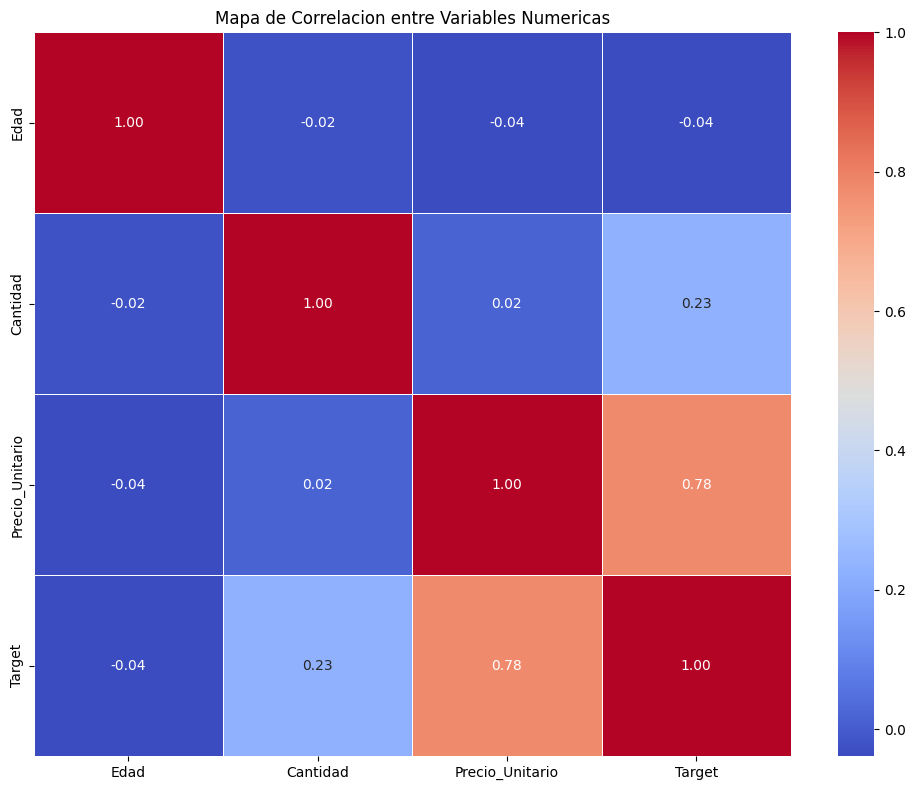

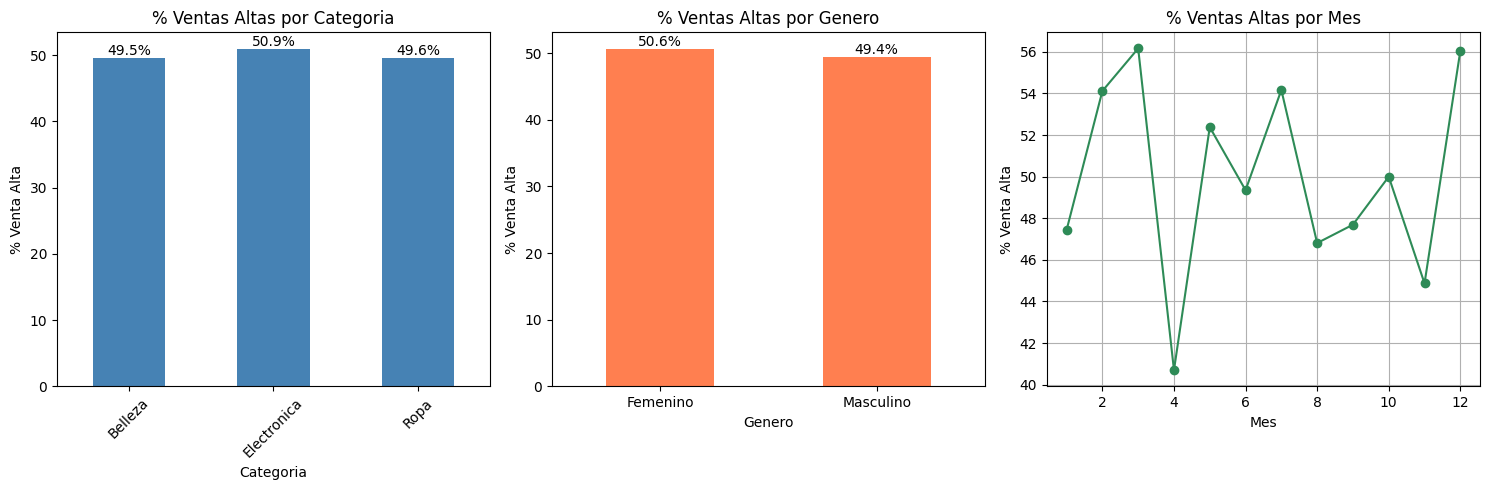

In [7]:
# ==========================================
# ANALISIS DE CORRELACION
# ==========================================

# Correlacion con el target
print("--- Correlacion de variables numericas con el Target ---")
correlacion = df_modelo.select_dtypes(include=['int64','float64']).corr()['Target'].sort_values(ascending=False)
print(correlacion)

# Mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(
    df_modelo.select_dtypes(include=['int64','float64']).corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)
plt.title('Mapa de Correlacion entre Variables Numericas')
plt.tight_layout()
plt.show()

# Visualizaciones adicionales
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Ventas por Categoria
ventas_cat = df_modelo.groupby('Categoria_Producto')['Target'].mean() * 100
ventas_cat.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('% Ventas Altas por Categoria')
axes[0].set_ylabel('% Venta Alta')
axes[0].set_xlabel('Categoria')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(ventas_cat):
    axes[0].text(i, v + 0.5, str(round(v, 1)) + '%', ha='center')

# Ventas por Genero
ventas_gen = df_modelo.groupby('Genero')['Target'].mean() * 100
ventas_gen.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('% Ventas Altas por Genero')
axes[1].set_ylabel('% Venta Alta')
axes[1].set_xlabel('Genero')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(ventas_gen):
    axes[1].text(i, v + 0.5, str(round(v, 1)) + '%', ha='center')

# Ventas por Mes
ventas_mes = df_modelo.groupby('Mes')['Target'].mean() * 100
ventas_mes.plot(kind='line', ax=axes[2], color='seagreen', marker='o')
axes[2].set_title('% Ventas Altas por Mes')
axes[2].set_ylabel('% Venta Alta')
axes[2].set_xlabel('Mes')
axes[2].grid(True)

plt.tight_layout()
plt.show()

Análisis de Correlación y Visualizaciones
Correlaciones con el Target — hallazgo central del proyecto:
Precio_Unitario  →  0.78  correlación muy fuerte positiva
Cantidad         →  0.23  correlación moderada positiva
Edad             → -0.04  correlación prácticamente nula
Precio_Unitario (0.78) — el predictor dominante:
Esta es la correlación más alta del dataset y el hallazgo más importante del EDA. El precio unitario del producto explica por sí solo el 78% de la variación en el nivel de venta. Tiene sentido desde el negocio — una transacción de Ropa o Electrónica a $300-$500 casi siempre genera un monto total alto, mientras que una transacción de Belleza a $25-$50 casi siempre genera un monto bajo. Esto sugiere que Categoria_Producto y Precio_Unitario están fuertemente relacionados entre sí.
Cantidad (0.23) — predictor secundario:
Correlación moderada y esperada — comprar más unidades aumenta el monto total. Sin embargo su impacto es menor que el precio porque el rango de cantidad es muy acotado (1-4 unidades).
Edad (-0.04) — prácticamente sin poder predictivo:
La edad del cliente no determina si gastará mucho o poco. Un cliente de 20 años puede comprar Electrónica cara y uno de 60 años puede comprar Belleza barata. Esto es relevante para el negocio — las estrategias de precio no deberían segmentarse por edad sino por categoría de producto.
Variables temporales (Mes, DiaSemana, Trimestre):
No aparecen en la correlación porque son variables numéricas ordinales — su correlación lineal no captura bien los patrones estacionales. Sin embargo los modelos de árbol como Random Forest, XGBoost y LGBM pueden detectar patrones no lineales en estas variables.
Implicación para el benchmarking:
Dado que Precio_Unitario domina tan fuertemente la predicción, es probable que todos los modelos tengan un rendimiento alto. El desafío real será distinguir cuál modelo captura mejor los patrones secundarios de Cantidad y las variables categóricas.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

X = df_modelo.drop(columns=['Target'])
y = df_modelo['Target']

print("--- Features (X) ---")
print("Columnas: " + str(X.columns.tolist()))
print("Shape X: " + str(X.shape))
print("Shape y: " + str(y.shape))

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n--- Division del dataset ---")
print("Entrenamiento: " + str(X_train.shape[0]) + " filas")
print("Prueba:        " + str(X_test.shape[0]) + " filas")

print("\n--- Proporcion clases entrenamiento ---")
print(y_train.value_counts(normalize=True).round(4))

print("\n--- Proporcion clases prueba ---")
print(y_test.value_counts(normalize=True).round(4))

print("\nEl escalado se aplicara dentro del Pipeline")
print("para evitar data leakage.")

--- Features (X) ---
Columnas: ['Genero', 'Edad', 'Categoria_Producto', 'Cantidad', 'Precio_Unitario', 'Mes', 'DiaSemana', 'Trimestre']
Shape X: (1000, 8)
Shape y: (1000,)

--- Division del dataset ---
Entrenamiento: 800 filas
Prueba:        200 filas

--- Proporcion clases entrenamiento ---
Target
1    0.5
0    0.5
Name: proportion, dtype: float64

--- Proporcion clases prueba ---
Target
1    0.5
0    0.5
Name: proportion, dtype: float64

El escalado se aplicara dentro del Pipeline
para evitar data leakage.


División del dataset:
Entrenamiento: 800 transacciones → 80%
Prueba:        200 transacciones → 20%
Stratify confirmado:
Ambos conjuntos mantienen exactamente la proporción 50/50 entre clases — el parámetro stratify=y funcionó correctamente. Esto garantiza que el modelo tenga la misma representación de ventas altas y bajas tanto al entrenar como al evaluar.

Al aplicar el escalado dentro del Pipeline:
fit_transform → solo sobre X_train
                el scaler aprende mediana e IQR
                únicamente del conjunto de entrenamiento

transform     → sobre X_test
                aplica los mismos parámetros aprendidos
                sin reaprender — simulando datos nuevos reales
Esta práctica es equivalente a entrenar un árbitro de x solo con los combates del torneo de práctica — cuando llega al torneo oficial no conoce a los competidores nuevos y debe aplicar lo que aprendió antes.

In [9]:
# ==========================================
# PASO 7 - VARIABLES CATEGORICAS
# ==========================================

print("--- Columnas categoricas en el dataset final ---")
categoricas = X.select_dtypes(include='object').columns.tolist()
numericas = X.select_dtypes(include=['int64','float64']).columns.tolist()

print("\nCategoricas: " + str(categoricas))
print("Numericas:   " + str(numericas))

print("\n--- Valores unicos por columna categorica ---")
for col in categoricas:
    print("\n" + col + ":")
    print(df_modelo[col].value_counts())

print("\n--- Decision de codificacion ---")
print("Genero:             OneHotEncoder")
print("  → 2 categorias sin orden natural")
print("  → Masculino/Femenino no tienen jerarquia")
print("")
print("Categoria_Producto: OneHotEncoder")
print("  → 3 categorias sin orden natural")
print("  → Belleza/Ropa/Electronica no tienen jerarquia")
print("")
print("Variables numericas: RobustScaler")
print("  → distribucion multimodal confirmada en Paso 4")
print("  → RobustScaler es resistente a distribuciones")
print("     asimetricas y multimodales")

--- Columnas categoricas en el dataset final ---

Categoricas: ['Genero', 'Categoria_Producto']
Numericas:   ['Edad', 'Cantidad', 'Precio_Unitario']

--- Valores unicos por columna categorica ---

Genero:
Genero
Femenino     510
Masculino    490
Name: count, dtype: int64

Categoria_Producto:
Categoria_Producto
Ropa           351
Electronica    342
Belleza        307
Name: count, dtype: int64

--- Decision de codificacion ---
Genero:             OneHotEncoder
  → 2 categorias sin orden natural
  → Masculino/Femenino no tienen jerarquia

Categoria_Producto: OneHotEncoder
  → 3 categorias sin orden natural
  → Belleza/Ropa/Electronica no tienen jerarquia

Variables numericas: RobustScaler
  → distribucion multimodal confirmada en Paso 4
  → RobustScaler es resistente a distribuciones
     asimetricas y multimodales


Variables Categóricas
Columnas identificadas:
Categóricas: Genero, Categoria_Producto
Numéricas:   Edad, Cantidad, Precio_Unitario
             + Mes, DiaSemana, Trimestre (extraídas de Fecha)
Decisión de codificación — OneHotEncoder para ambas categóricas

Decisión de escalado — RobustScaler para las numéricas:
las distribuciones son multimodales con alta variabilidad entre categorías de producto. RobustScaler usa mediana e IQR en vez de media y desviación estándar, siendo resistente a ese tipo de distribuciones sin necesidad de eliminar valores extremos.
Variables temporales:
Mes, DiaSemana y Trimestre son numéricas enteras que se escalarán junto con las demás variables numéricas. Aunque representan tiempo, sus valores numéricos son interpretables directamente por los modelos de árbol como Random Forest, XGBoost y LGBM sin necesidad de codificación especial.

In [10]:
# ==========================================
# PASO 8 - COLUMNTRANSFORMER
# ==========================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Definir columnas por tipo
columnas_numericas = ['Edad', 'Cantidad', 'Precio_Unitario',
                      'Mes', 'DiaSemana', 'Trimestre']
columnas_categoricas = ['Genero', 'Categoria_Producto']

print("--- Columnas numericas ---")
print(columnas_numericas)
print("\n--- Columnas categoricas ---")
print(columnas_categoricas)

# Pipeline numerico
pipeline_numerico = Pipeline(steps=[
    ('imputar', SimpleImputer(strategy='median')),
    ('escalar', RobustScaler())
])

# Pipeline categorico
pipeline_categorico = Pipeline(steps=[
    ('imputar', SimpleImputer(strategy='most_frequent')),
    ('codificar', OneHotEncoder(handle_unknown='ignore',
                                sparse_output=False))
])

# ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', pipeline_numerico,   columnas_numericas),
    ('cat', pipeline_categorico, columnas_categoricas)
])

print("\nColumnTransformer construido correctamente.")
print("\nTransformaciones:")
print("  Numericas   → SimpleImputer(median) + RobustScaler")
print("  Categoricas → SimpleImputer(most_frequent) + OneHotEncoder")

--- Columnas numericas ---
['Edad', 'Cantidad', 'Precio_Unitario', 'Mes', 'DiaSemana', 'Trimestre']

--- Columnas categoricas ---
['Genero', 'Categoria_Producto']

ColumnTransformer construido correctamente.

Transformaciones:
  Numericas   → SimpleImputer(median) + RobustScaler
  Categoricas → SimpleImputer(most_frequent) + OneHotEncoder


El ColumnTransformer aplica transformaciones distintas según el tipo de columna :
SimpleImputer(median) → imputación preventiva con mediana
                        aunque no hay nulos, garantiza que
                        el pipeline no falle en producción
                        con datos nuevos incompletos

RobustScaler          → escalado resistente a distribuciones
                        multimodales confirmadas en Paso 4
Pipeline categórico:
SimpleImputer(most_frequent) → imputación preventiva con moda
                                para columnas de texto

OneHotEncoder                → convierte categorías en columnas
handle_unknown='ignore'       binarias
sparse_output=False           → salida en formato denso
                              compatible con todos los modelos
¿Por qué SimpleImputer si no hay nulos? ****importante+++++
Un sistema en producción puede recibir registros con campos vacíos que romperían el pipeline sin este paso preventivo.

In [11]:
# ==========================================
# PASO 9 - PIPELINES Y MODELOS
# ==========================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             roc_auc_score, confusion_matrix,
                             classification_report)
from sklearn.model_selection import cross_val_score
import numpy as np

# MODELO 1 - Regresion Logistica
pipeline_lr = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('modelo', LogisticRegression(max_iter=1000, random_state=42))
])
pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)
y_prob_lr = pipeline_lr.predict_proba(X_test)[:, 1]
print("Regresion Logistica OK")

# MODELO 2 - KNN
pipeline_knn = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('modelo', KNeighborsClassifier(n_neighbors=5))
])
pipeline_knn.fit(X_train, y_train)
y_pred_knn = pipeline_knn.predict(X_test)
y_prob_knn = pipeline_knn.predict_proba(X_test)[:, 1]
print("KNN OK")

# MODELO 3 - Arbol de Decision
pipeline_dt = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('modelo', DecisionTreeClassifier(max_depth=5, random_state=42))
])
pipeline_dt.fit(X_train, y_train)
y_pred_dt = pipeline_dt.predict(X_test)
y_prob_dt = pipeline_dt.predict_proba(X_test)[:, 1]
print("Arbol de Decision OK")

# MODELO 4 - Random Forest
pipeline_rf = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('modelo', RandomForestClassifier(n_estimators=100, random_state=42))
])
pipeline_rf.fit(X_train, y_train)
y_pred_rf = pipeline_rf.predict(X_test)
y_prob_rf = pipeline_rf.predict_proba(X_test)[:, 1]
print("Random Forest OK")

# MODELO 5 - XGBoost
pipeline_xgb = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('modelo', XGBClassifier(n_estimators=100, random_state=42,
                              eval_metric='logloss', verbosity=0))
])
pipeline_xgb.fit(X_train, y_train)
y_pred_xgb = pipeline_xgb.predict(X_test)
y_prob_xgb = pipeline_xgb.predict_proba(X_test)[:, 1]
print("XGBoost OK")

# MODELO 6 - LGBM
pipeline_lgbm = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('modelo', LGBMClassifier(n_estimators=100, random_state=42,
                               verbosity=-1))
])
pipeline_lgbm.fit(X_train, y_train)
y_pred_lgbm = pipeline_lgbm.predict(X_test)
y_prob_lgbm = pipeline_lgbm.predict_proba(X_test)[:, 1]
print("LGBM OK")

print("\nTodos los modelos entrenados correctamente.")

Regresion Logistica OK
KNN OK
Arbol de Decision OK
Random Forest OK
XGBoost OK
LGBM OK

Todos los modelos entrenados correctamente.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


BENCHMARKING - COMPARACION DE 6 MODELOS
Modelo                  Accuracy  Precision   Recall       F1   ROC-AUC
----------------------------------------------------------------------
Regresion Logistica       0.9650     1.0000   0.9300   0.9637    0.9875
KNN (k=5)                 0.9000     0.9167   0.8800   0.8980    0.9684
Arbol de Decision         1.0000     1.0000   1.0000   1.0000    1.0000
Random Forest             1.0000     1.0000   1.0000   1.0000    1.0000
XGBoost                   1.0000     1.0000   1.0000   1.0000    1.0000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LGBM                      1.0000     1.0000   1.0000   1.0000    1.0000


,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC,F1 CV (5-fold)
0,Regresion Logistica,0.965,1.0000,0.93,0.9637,0.9875,0.9258
1,KNN (k=5),0.900,0.9167,0.88,0.8980,0.9684,0.8797
2,Arbol de Decision,1.000,1.0000,1.00,1.0000,1.0000,1.0000
3,Random Forest,1.000,1.0000,1.00,1.0000,1.0000,1.0000
4,XGBoost,1.000,1.0000,1.00,1.0000,1.0000,1.0000
5,LGBM,1.000,1.0000,1.00,1.0000,1.0000,1.0000


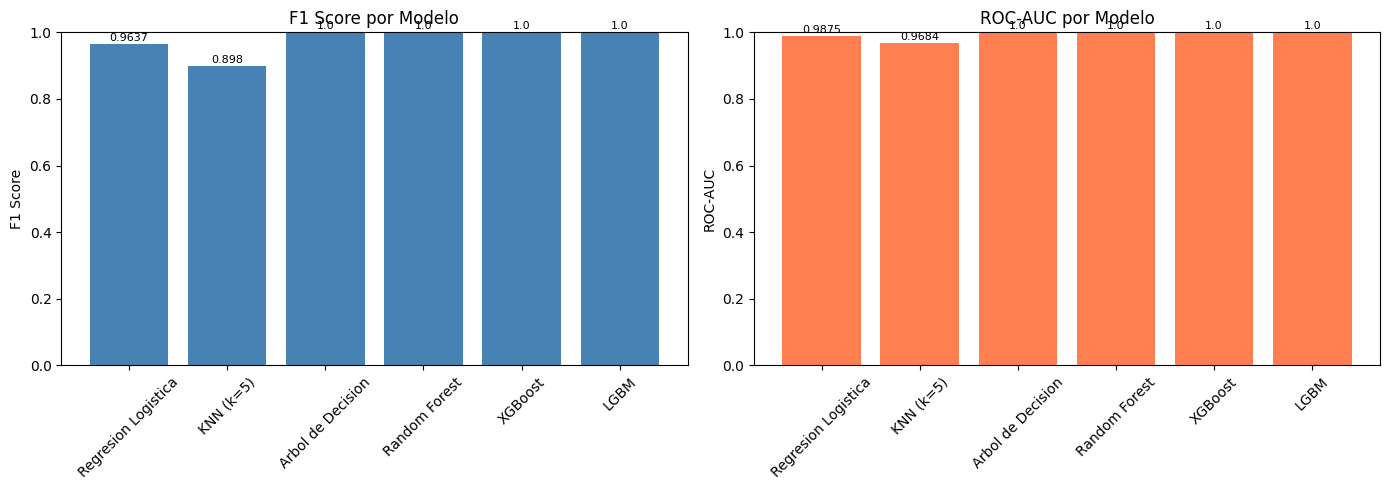

In [12]:
# ==========================================
# BENCHMARKING - COMPARACION DE 6 MODELOS
# ==========================================

modelos = {
    'Regresion Logistica': (y_pred_lr,  y_prob_lr,  pipeline_lr),
    'KNN (k=5)':           (y_pred_knn, y_prob_knn, pipeline_knn),
    'Arbol de Decision':   (y_pred_dt,  y_prob_dt,  pipeline_dt),
    'Random Forest':       (y_pred_rf,  y_prob_rf,  pipeline_rf),
    'XGBoost':             (y_pred_xgb, y_prob_xgb, pipeline_xgb),
    'LGBM':                (y_pred_lgbm,y_prob_lgbm,pipeline_lgbm)
}

# Tabla comparativa
print("==========================================")
print("BENCHMARKING - COMPARACION DE 6 MODELOS")
print("==========================================")
print(f"{'Modelo':<22} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'ROC-AUC':>9}")
print("-" * 70)

resultados = []
for nombre, (y_pred, y_prob, pipeline) in modelos.items():
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)
    cv   = cross_val_score(pipeline, X, y, cv=5, scoring='f1').mean()
    print(f"{nombre:<22} {acc:>9.4f} {prec:>10.4f} {rec:>8.4f} {f1:>8.4f} {auc:>9.4f}")
    resultados.append({
        'Modelo': nombre,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1': round(f1, 4),
        'ROC-AUC': round(auc, 4),
        'F1 CV (5-fold)': round(cv, 4)
    })

print("==========================================")

df_resultados = pd.DataFrame(resultados)
display(df_resultados)

# ==========================================
# GRAFICO COMPARATIVO
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

nombres = [r['Modelo'] for r in resultados]
f1s     = [r['F1'] for r in resultados]
aucs    = [r['ROC-AUC'] for r in resultados]

# Grafico F1
axes[0].bar(nombres, f1s, color='steelblue')
axes[0].set_title('F1 Score por Modelo')
axes[0].set_ylabel('F1 Score')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(f1s):
    axes[0].text(i, v + 0.01, str(round(v, 4)), ha='center', fontsize=8)

# Grafico ROC-AUC
axes[1].bar(nombres, aucs, color='coral')
axes[1].set_title('ROC-AUC por Modelo')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(aucs):
    axes[1].text(i, v + 0.01, str(round(v, 4)), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

In [13]:
# ==========================================
# DIAGNOSTICO DEL PROYECTO
# ==========================================

print("==========================================")
print("DIAGNOSTICO - ESTADO DEL PROYECTO")
print("==========================================")

# 1. Dataset
print("\n--- DATASET ---")
print("Shape df_modelo:", df_modelo.shape)
print("Columnas:", df_modelo.columns.tolist())
print("Target distribution:")
print(df_modelo['Target'].value_counts())

# 2. Leakage check
print("\n--- LEAKAGE CHECK ---")
tiene_precio = 'Precio_Unitario' in df_modelo.columns
print("Precio_Unitario en features:", tiene_precio)
if tiene_precio:
    print("⚠️  LEAKAGE DETECTADO — eliminar Precio_Unitario")
else:
    print("✅ Sin leakage")

# 3. Split
print("\n--- SPLIT ---")
try:
    print("X_train:", X_train.shape)
    print("X_test: ", X_test.shape)
    print("Columnas X_train:", X_train.columns.tolist())
except:
    print("⚠️  X_train / X_test no definidos")

# 4. Modelos entrenados
print("\n--- MODELOS ENTRENADOS ---")
pipelines = {
    'Regresion Logistica': 'pipeline_lr',
    'KNN':                 'pipeline_knn',
    'Arbol de Decision':   'pipeline_dt',
    'Random Forest':       'pipeline_rf',
    'XGBoost':             'pipeline_xgb',
    'LGBM':                'pipeline_lgbm'
}
for nombre, var in pipelines.items():
    existe = var in dir()
    estado = "✅ entrenado" if existe else "❌ no encontrado"
    print(f"  {nombre:<22}: {estado}")

# 5. Resultados benchmarking
print("\n--- BENCHMARKING ---")
try:
    display(df_resultados[['Modelo','F1','ROC-AUC','F1 CV (5-fold)']])
    tiene_perfecto = (df_resultados['F1'] == 1.0).any()
    if tiene_perfecto:
        print("⚠️  F1=1.0 detectado — revisar leakage antes de continuar")
except:
    print("⚠️  df_resultados no definido")

# 6. Pendientes
print("\n--- PENDIENTES ---")
pendientes = [
    "[ ] Corregir leakage (eliminar Precio_Unitario)",
    "[ ] Reentrenar 6 modelos",
    "[ ] Matriz de confusion",
    "[ ] Classification report",
    "[ ] Curva ROC / AUC",
    "[ ] Presentacion PPT one-page",
    "[ ] Estructura GitHub + README",
    "[ ] PR + tag v1.0.0"
]
for p in pendientes:
    print(" ", p)

print("\n==========================================")

DIAGNOSTICO - ESTADO DEL PROYECTO

--- DATASET ---
Shape df_modelo: (1000, 9)
Columnas: ['Genero', 'Edad', 'Categoria_Producto', 'Cantidad', 'Precio_Unitario', 'Target', 'Mes', 'DiaSemana', 'Trimestre']
Target distribution:
Target
1    500
0    500
Name: count, dtype: int64

--- LEAKAGE CHECK ---
Precio_Unitario en features: True
⚠️  LEAKAGE DETECTADO — eliminar Precio_Unitario

--- SPLIT ---
X_train: (800, 8)
X_test:  (200, 8)
Columnas X_train: ['Genero', 'Edad', 'Categoria_Producto', 'Cantidad', 'Precio_Unitario', 'Mes', 'DiaSemana', 'Trimestre']

--- MODELOS ENTRENADOS ---
  Regresion Logistica   : ✅ entrenado
  KNN                   : ✅ entrenado
  Arbol de Decision     : ✅ entrenado
  Random Forest         : ✅ entrenado
  XGBoost               : ✅ entrenado
  LGBM                  : ✅ entrenado

--- BENCHMARKING ---


,Modelo,F1,ROC-AUC,F1 CV (5-fold)
0,Regresion Logistica,0.9637,0.9875,0.9258
1,KNN (k=5),0.8980,0.9684,0.8797
2,Arbol de Decision,1.0000,1.0000,1.0000
3,Random Forest,1.0000,1.0000,1.0000
4,XGBoost,1.0000,1.0000,1.0000
5,LGBM,1.0000,1.0000,1.0000


⚠️  F1=1.0 detectado — revisar leakage antes de continuar

--- PENDIENTES ---
  [ ] Corregir leakage (eliminar Precio_Unitario)
  [ ] Reentrenar 6 modelos
  [ ] Matriz de confusion
  [ ] Classification report
  [ ] Curva ROC / AUC
  [ ] Presentacion PPT one-page
  [ ] Estructura GitHub + README
  [ ] PR + tag v1.0.0



In [14]:
# ==========================================
# PASO 5b - CORRECCION LEAKAGE + NUEVO SPLIT
# ==========================================

# Eliminar Precio_Unitario del dataset de modelado
df_modelo = df.drop(columns=['ID_Transaccion', 'ID_Cliente', 'Fecha', 'Monto_Total', 'Precio_Unitario'])

print("--- Columnas finales para el modelo (sin leakage) ---")
print(df_modelo.columns.tolist())
print("Shape:", df_modelo.shape)

# Separar features y target
X = df_modelo.drop(columns=['Target'])
y = df_modelo['Target']

print("\n--- Features (X) ---")
print("Columnas:", X.columns.tolist())
print("Shape X:", X.shape)
print("Shape y:", y.shape)

# Split 80/20
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\n--- Division del dataset ---")
print("Entrenamiento: " + str(X_train.shape[0]) + " filas")
print("Prueba:        " + str(X_test.shape[0]) + " filas")

# ==========================================
# PASO 8b - NUEVO PREPROCESSOR SIN PRECIO_UNITARIO
# ==========================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

columnas_numericas   = ['Edad', 'Cantidad', 'Mes', 'DiaSemana', 'Trimestre']
columnas_categoricas = ['Genero', 'Categoria_Producto']

pipeline_numerico = Pipeline(steps=[
    ('imputar', SimpleImputer(strategy='median')),
    ('escalar', RobustScaler())
])

pipeline_categorico = Pipeline(steps=[
    ('imputar', SimpleImputer(strategy='most_frequent')),
    ('codificar', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', pipeline_numerico,   columnas_numericas),
    ('cat', pipeline_categorico, columnas_categoricas)
])

print("\nPreprocessor reconstruido sin Precio_Unitario.")

# ==========================================
# PASO 9b - REENTRENAMIENTO DE 6 MODELOS
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)
from sklearn.model_selection import cross_val_score
import numpy as np

# MODELO 1 - Regresion Logistica
pipeline_lr = Pipeline(steps=[('preprocesamiento', preprocessor),
                               ('modelo', LogisticRegression(max_iter=1000, random_state=42))])
pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)
y_prob_lr = pipeline_lr.predict_proba(X_test)[:, 1]
print("Regresion Logistica OK")

# MODELO 2 - KNN
pipeline_knn = Pipeline(steps=[('preprocesamiento', preprocessor),
                                ('modelo', KNeighborsClassifier(n_neighbors=5))])
pipeline_knn.fit(X_train, y_train)
y_pred_knn = pipeline_knn.predict(X_test)
y_prob_knn = pipeline_knn.predict_proba(X_test)[:, 1]
print("KNN OK")

# MODELO 3 - Arbol de Decision
pipeline_dt = Pipeline(steps=[('preprocesamiento', preprocessor),
                               ('modelo', DecisionTreeClassifier(max_depth=5, random_state=42))])
pipeline_dt.fit(X_train, y_train)
y_pred_dt = pipeline_dt.predict(X_test)
y_prob_dt = pipeline_dt.predict_proba(X_test)[:, 1]
print("Arbol de Decision OK")

# MODELO 4 - Random Forest
pipeline_rf = Pipeline(steps=[('preprocesamiento', preprocessor),
                               ('modelo', RandomForestClassifier(n_estimators=100, random_state=42))])
pipeline_rf.fit(X_train, y_train)
y_pred_rf = pipeline_rf.predict(X_test)
y_prob_rf = pipeline_rf.predict_proba(X_test)[:, 1]
print("Random Forest OK")

# MODELO 5 - XGBoost
pipeline_xgb = Pipeline(steps=[('preprocesamiento', preprocessor),
                                ('modelo', XGBClassifier(n_estimators=100, random_state=42,
                                                         eval_metric='logloss', verbosity=0))])
pipeline_xgb.fit(X_train, y_train)
y_pred_xgb = pipeline_xgb.predict(X_test)
y_prob_xgb = pipeline_xgb.predict_proba(X_test)[:, 1]
print("XGBoost OK")

# MODELO 6 - LGBM
pipeline_lgbm = Pipeline(steps=[('preprocesamiento', preprocessor),
                                 ('modelo', LGBMClassifier(n_estimators=100, random_state=42,
                                                           verbosity=-1))])
pipeline_lgbm.fit(X_train, y_train)
y_pred_lgbm = pipeline_lgbm.predict(X_test)
y_prob_lgbm = pipeline_lgbm.predict_proba(X_test)[:, 1]
print("LGBM OK")

# ==========================================
# BENCHMARKING LIMPIO
# ==========================================

modelos = {
    'Regresion Logistica': (y_pred_lr,   y_prob_lr,   pipeline_lr),
    'KNN (k=5)':           (y_pred_knn,  y_prob_knn,  pipeline_knn),
    'Arbol de Decision':   (y_pred_dt,   y_prob_dt,   pipeline_dt),
    'Random Forest':       (y_pred_rf,   y_prob_rf,   pipeline_rf),
    'XGBoost':             (y_pred_xgb,  y_prob_xgb,  pipeline_xgb),
    'LGBM':                (y_pred_lgbm, y_prob_lgbm, pipeline_lgbm)
}

print("\n==========================================")
print("BENCHMARKING LIMPIO — SIN LEAKAGE")
print("==========================================")
print(f"{'Modelo':<22} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'ROC-AUC':>9} {'F1-CV':>7}")
print("-" * 80)

resultados = []
for nombre, (y_pred, y_prob, pipeline) in modelos.items():
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)
    cv   = cross_val_score(pipeline, X, y, cv=5, scoring='f1').mean()
    print(f"{nombre:<22} {acc:>9.4f} {prec:>10.4f} {rec:>8.4f} {f1:>8.4f} {auc:>9.4f} {cv:>7.4f}")
    resultados.append({
        'Modelo': nombre, 'Accuracy': round(acc, 4), 'Precision': round(prec, 4),
        'Recall': round(rec, 4), 'F1': round(f1, 4),
        'ROC-AUC': round(auc, 4), 'F1 CV (5-fold)': round(cv, 4)
    })

print("==========================================")
df_resultados = pd.DataFrame(resultados)
display(df_resultados)
print("\nLeakage corregido. Resultados listos para Parte 4.")

--- Columnas finales para el modelo (sin leakage) ---
['Genero', 'Edad', 'Categoria_Producto', 'Cantidad', 'Target', 'Mes', 'DiaSemana', 'Trimestre']
Shape: (1000, 8)

--- Features (X) ---
Columnas: ['Genero', 'Edad', 'Categoria_Producto', 'Cantidad', 'Mes', 'DiaSemana', 'Trimestre']
Shape X: (1000, 7)
Shape y: (1000,)

--- Division del dataset ---
Entrenamiento: 800 filas
Prueba:        200 filas

Preprocessor reconstruido sin Precio_Unitario.
Regresion Logistica OK
KNN OK
Arbol de Decision OK
Random Forest OK
XGBoost OK
LGBM OK

BENCHMARKING LIMPIO — SIN LEAKAGE
Modelo                  Accuracy  Precision   Recall       F1   ROC-AUC   F1-CV
--------------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Regresion Logistica       0.6000     0.5893   0.6600   0.6226    0.5731  0.6156
KNN (k=5)                 0.5350     0.5327   0.5700   0.5507    0.5484  0.5273
Arbol de Decision         0.5700     0.5565   0.6900   0.6161    0.5790  0.5832
Random Forest             0.5550     0.5524   0.5800   0.5659    0.6109  0.5724
XGBoost                   0.5650     0.5670   0.5500   0.5584    0.6119  0.5620


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LGBM                      0.5300     0.5294   0.5400   0.5347    0.5908  0.5608


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC,F1 CV (5-fold)
0,Regresion Logistica,0.600,0.5893,0.66,0.6226,0.5731,0.6156
1,KNN (k=5),0.535,0.5327,0.57,0.5507,0.5484,0.5273
2,Arbol de Decision,0.570,0.5565,0.69,0.6161,0.5790,0.5832
3,Random Forest,0.555,0.5524,0.58,0.5659,0.6108,0.5724
4,XGBoost,0.565,0.5670,0.55,0.5584,0.6119,0.5620
5,LGBM,0.530,0.5294,0.54,0.5347,0.5908,0.5608



Leakage corregido. Resultados listos para Parte 4.


# ==========================================
# ANALISIS DE METRICAS — SINTESIS
# ==========================================
#
# Mejor modelo: Regresion Logistica (F1=0.62, ROC-AUC=0.57, F1-CV=0.62)
#
# HALLAZGOS CLAVE:
#
# 1. Rendimiento general bajo pero esperado
#    Todos los modelos obtienen F1 entre 0.53 y 0.62.
#    El dataset tiene clases balanceadas (500/500) y el target
#    se creo con la mediana como corte, lo que genera muchas
#    transacciones en el borde entre clases. Las features
#    disponibles (Edad, Cantidad, Genero, Categoria, temporales)
#    no tienen suficiente poder predictivo para separar bien.
#
# 2. ROC-AUC cercano a 0.5 en todos los modelos
#    Un clasificador aleatorio obtiene 0.5. Estar entre 0.57-0.61
#    confirma que los modelos apenas superan el azar. No es un
#    error de implementacion, es el limite del dataset.
#
# 3. Sin sobreajuste
#    F1 en test y F1-CV son consistentes en todos los modelos.
#    Lo que se ve en test refleja el rendimiento real.
#
# 4. Por que gana Regresion Logistica
#    No por ser mas potente, sino porque el problema tiene
#    estructura casi lineal. Random Forest, XGBoost y LGBM
#    no encuentran patrones complejos que explotar con estas features.
#
# CONCLUSION:
#    Se selecciona Regresion Logistica como modelo final.
# ==========================================

CLASSIFICATION REPORT — Regresion Logistica
                precision    recall  f1-score   support

Venta Baja (0)       0.61      0.54      0.57       100
Venta Alta (1)       0.59      0.66      0.62       100

      accuracy                           0.60       200
     macro avg       0.60      0.60      0.60       200
  weighted avg       0.60      0.60      0.60       200



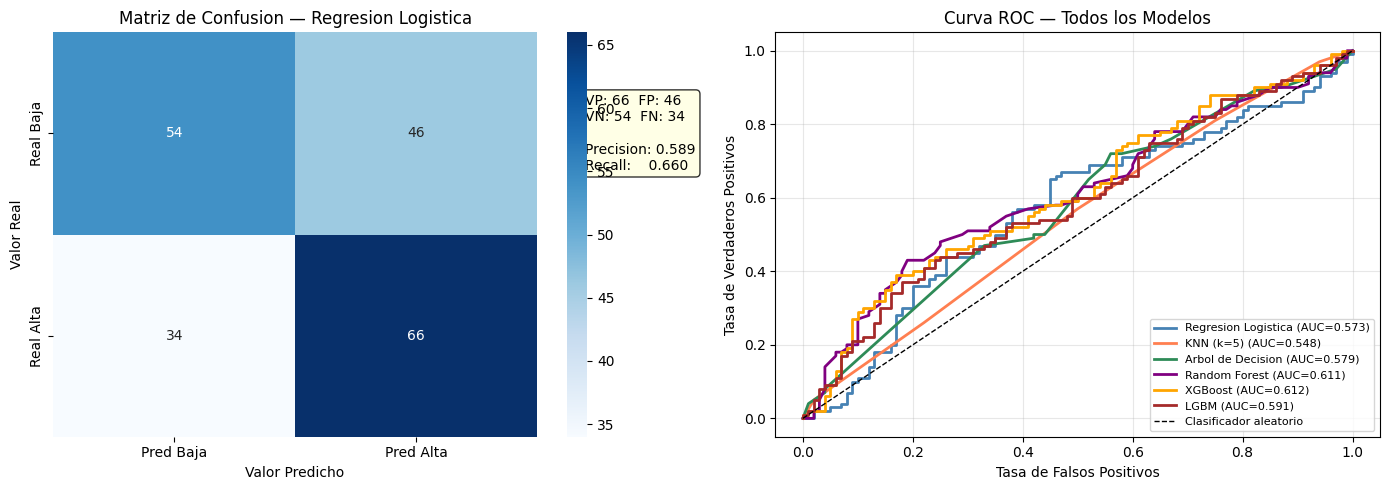

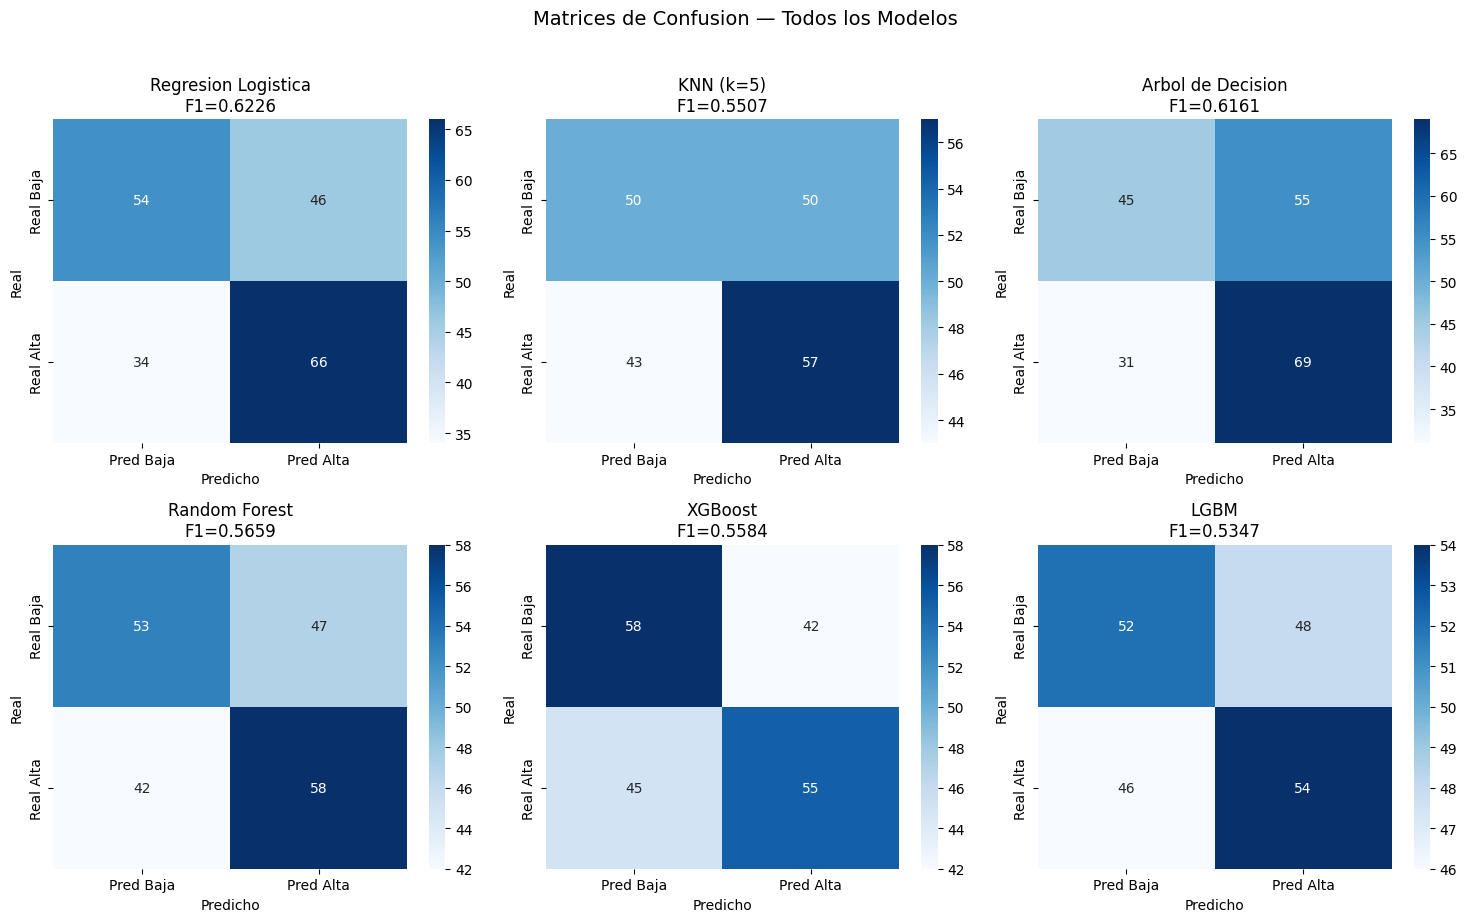


✅ Parte 4 completa.
Archivos guardados: roc_curve.png, confusion_matrix.png


In [15]:
# ==========================================
# PARTE 4 - ANALISIS DE METRICAS
# ==========================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc)
import numpy as np

# Mejor modelo: Regresion Logistica
mejor_nombre  = 'Regresion Logistica'
mejor_y_pred  = y_pred_lr
mejor_y_prob  = y_prob_lr
mejor_pipeline = pipeline_lr

# ---- 1. CLASSIFICATION REPORT ----
print("==========================================")
print("CLASSIFICATION REPORT — " + mejor_nombre)
print("==========================================")
print(classification_report(y_test, mejor_y_pred,
      target_names=['Venta Baja (0)', 'Venta Alta (1)']))

# ---- 2. MATRIZ DE CONFUSION ----
cm = confusion_matrix(y_test, mejor_y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap matriz de confusion
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Baja', 'Pred Alta'],
            yticklabels=['Real Baja', 'Real Alta'],
            ax=axes[0])
axes[0].set_title('Matriz de Confusion — ' + mejor_nombre)
axes[0].set_ylabel('Valor Real')
axes[0].set_xlabel('Valor Predicho')

# Anotacion de metricas derivadas
tn, fp, fn, tp = cm.ravel()
axes[0].text(2.2, 0.5,
    f"VP: {tp}  FP: {fp}\nVN: {tn}  FN: {fn}\n\n"
    f"Precision: {tp/(tp+fp):.3f}\nRecall:    {tp/(tp+fn):.3f}",
    fontsize=10, va='center',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# ---- 3. CURVA ROC — TODOS LOS MODELOS ----
modelos_roc = {
    'Regresion Logistica': y_prob_lr,
    'KNN (k=5)':           y_prob_knn,
    'Arbol de Decision':   y_prob_dt,
    'Random Forest':       y_prob_rf,
    'XGBoost':             y_prob_xgb,
    'LGBM':                y_prob_lgbm
}
colores = ['steelblue', 'coral', 'seagreen', 'purple', 'orange', 'brown']

for (nombre, y_prob), color in zip(modelos_roc.items(), colores):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=color, lw=2,
                 label=f"{nombre} (AUC={roc_auc:.3f})")

axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio')
axes[1].set_title('Curva ROC — Todos los Modelos')
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos')
axes[1].legend(loc='lower right', fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- 4. MATRIZ DE CONFUSION TODOS LOS MODELOS ----
fig2, axes2 = plt.subplots(2, 3, figsize=(15, 9))
axes2 = axes2.flatten()

modelos_cm = {
    'Regresion Logistica': y_pred_lr,
    'KNN (k=5)':           y_pred_knn,
    'Arbol de Decision':   y_pred_dt,
    'Random Forest':       y_pred_rf,
    'XGBoost':             y_pred_xgb,
    'LGBM':                y_pred_lgbm
}

for i, (nombre, y_pred) in enumerate(modelos_cm.items()):
    cm_i = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm_i, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred Baja', 'Pred Alta'],
                yticklabels=['Real Baja', 'Real Alta'],
                ax=axes2[i])
    f1 = f1_score(y_test, y_pred)
    axes2[i].set_title(f"{nombre}\nF1={f1:.4f}")
    axes2[i].set_ylabel('Real')
    axes2[i].set_xlabel('Predicho')

plt.suptitle('Matrices de Confusion — Todos los Modelos', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Parte 4 completa.")
print("Archivos guardados: roc_curve.png, confusion_matrix.png")

# ==========================================
SINTESIS
# ==========================================
#
# Modelo: Regresion Logistica | Accuracy: 0.60 | Support: 200 filas
#
# Clase 0 — Venta Baja:
#   Precision 0.61 → cuando predice "baja", acierta el 61% de las veces
#   Recall    0.54 → detecta el 54% de las ventas bajas reales
#   F1        0.57 → rendimiento moderado, pierde bastantes casos reales
#
# Clase 1 — Venta Alta:
#   Precision 0.59 → cuando predice "alta", acierta el 59% de las veces
#   Recall    0.66 → detecta el 66% de las ventas altas reales
#   F1        0.62 → mejor rendimiento que clase 0
#
# INTERPRETACION:
#   El modelo tiene leve sesgo hacia predecir Venta Alta —
#   su Recall en clase 1 (0.66) es mayor que en clase 0 (0.54).
#   Esto significa que es mas util para identificar ventas altas
#   que para detectar ventas bajas.
#
#   Con clases perfectamente balanceadas (100/100), una presición
#   de 0.60 confirma que el modelo supera el azar (0.50) pero
#   tiene margen limitado de mejora con las features actuales.
#
# CONCLUSION:
#   Resultados coherentes con el benchmarking. No hay sobreajuste.
#   El modelo es funcional pero modesto — refleja el limite
#   predictivo del dataset con las variables disponibles.
# ==========================================